# raw_data vs. cleaned data
### 수빈님 코드 base로 해서 작성된 결과물입니다
데이터 경로 수정해서 써주세요

In [1]:
import re
import pandas as pd
from langchain_text_splitters import RecursiveCharacterTextSplitter

print("🚀 [Step 2] 정제 ➡️ 청킹 ➡️ 메타데이터 주입 통합 파이프라인 시작...\n")

# 1. 원본 데이터 불러오기

################### 경로 수정 필수 ##################
file_path = '/home/bidcoin/bid_master_cleaned.csv'  # <-- 데이터 경로 수정 필수
df = pd.read_csv(file_path)
print(f"✅ 원본 데이터: 총 {len(df)}건\n")

# 통합된 클리닝 & 청킹 & 메타데이터 주입 함수
def clean_and_chunk_with_meta(row):
    raw_text = row['텍스트']
    
    if pd.isna(raw_text) or len(str(raw_text)) == 0:
        return []
    
    # ------------------------------------------------------------
    # 🧹 [Step 1] 텍스트 정제
    # ------------------------------------------------------------
    cleaned_text = re.sub(r'[^가-힣a-zA-Z0-9\s\.\(\)\[\]\/\,\%\:\-\·\?\!\@]', ' ', str(raw_text))
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    cleaned_len = len(cleaned_text)
    
    # ------------------------------------------------------------
    # ✂️ [Step 2] 맞춤형 청킹
    # ------------------------------------------------------------
    if cleaned_len < 500:
        chunk_size = 500
        chunk_overlap = 0
    elif cleaned_len < 3000:
        chunk_size = 512
        chunk_overlap = 50
    elif cleaned_len < 10000:
        chunk_size = 512
        chunk_overlap = 100
    else:
        chunk_size = 1024
        chunk_overlap = 200

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    chunks = splitter.split_text(cleaned_text)
    
    # ------------------------------------------------------------
    # 🏷️ [Step 3] 메타데이터 주입 (디테일 업그레이드!)
    # ------------------------------------------------------------
    chunks_with_meta = []
    
    # 결측치(NaN)를 '미상' 또는 빈 문자열로 안전하게 변환하는 헬퍼 함수
    def safe_str(val):
        return "미상" if pd.isna(val) else str(val)
    
    # 금액 포맷팅 안전장치
    try:
        amt_str = f"{float(row['사업 금액']):,.0f}원" if not pd.isna(row['사업 금액']) else "미상"
    except:
        amt_str = safe_str(row['사업 금액'])
        
    # 날짜와 공고번호 가져오기 (컬럼이 없을 경우를 대비해 get 메서드 사용)
    notice_id = safe_str(row.get('공고 번호', '미상'))
    start_date = safe_str(row.get('입찰 참여 시작일', '미상'))
    
    total_chunks = len(chunks)
    
    for i, chunk_text in enumerate(chunks):
        # 조각 순서(i+1/total)와 날짜/공고번호 추가
        meta_header = (
            f"[공고번호: {notice_id} | 발주기관: {safe_str(row['발주 기관'])} | "
            f"사업명: {safe_str(row['사업명'])} | 금액: {amt_str} | "
            f"시작일: {start_date} | 조각순서: {i+1}/{total_chunks}]"
        )
        chunk_with_meta = f"{meta_header}\n\n{chunk_text}"
        chunks_with_meta.append(chunk_with_meta)
        
    return chunks_with_meta

# 3. 데이터프레임에 통합 함수 적용
print("✂️ 텍스트 정제, 청킹, 이름표 부착을 동시에 진행합니다. 잠시만 기다려주세요...")
df['청크_리스트'] = df.apply(clean_and_chunk_with_meta, axis=1)

# 4. 쪼개진 리스트를 각각의 행(Row)으로 분리 (데이터 폭발! 💥)
chunked_df = df.explode('청크_리스트').reset_index(drop=True)

# 5. 컬럼 정리 및 새로운 텍스트 길이 계산
chunked_df = chunked_df.rename(columns={'청크_리스트': '청크_텍스트'})

# 원본 '텍스트'와 '텍스트길이' 컬럼은 삭제하여 메모리 확보 (에러 방지용 errors='ignore' 추가)
chunked_df = chunked_df.drop(columns=['텍스트', '텍스트길이'], errors='ignore')

# 최종 청크_텍스트의 글자 수 다시 세기
chunked_df['청크_길이'] = chunked_df['청크_텍스트'].apply(lambda x: len(x) if isinstance(x, str) else 0)

# 6. 최종 완성 데이터 저장


################### 경로 수정 필수 ##################
save_path = '/home/bidcoin/bid_master_chunked.csv' ######## <-- 결과 저장 경로 수정 필수
chunked_df.to_csv(save_path, index=False, encoding='utf-8-sig')

print("-" * 60)
print(f"✨ 작업 완료! 원본 {len(df)}건의 문서가 총 {len(chunked_df)}개의 완벽한 조각으로 나누어졌습니다.")
print(f"💾 결과물이 '{save_path}'에 안전하게 저장되었습니다!")

# 결과 샘플 확인
display(chunked_df[['파일명', '청크_텍스트', '청크_길이']].head())

🚀 [Step 2] 정제 ➡️ 청킹 ➡️ 메타데이터 주입 통합 파이프라인 시작...

✅ 원본 데이터: 총 100건

✂️ 텍스트 정제, 청킹, 이름표 부착을 동시에 진행합니다. 잠시만 기다려주세요...
------------------------------------------------------------
✨ 작업 완료! 원본 100건의 문서가 총 960개의 완벽한 조각으로 나누어졌습니다.
💾 결과물이 '/home/bidcoin/bid_master_chunked.csv'에 안전하게 저장되었습니다!


,파일명,청크_텍스트,청크_길이
0,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,[공고번호: 20241001798 | 발주기관: 한영대학 | 사업명: 한영대학교 특...,471
1,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,[공고번호: 20241001798 | 발주기관: 한영대학 | 사업명: 한영대학교 특...,634
2,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,[공고번호: 20241001798 | 발주기관: 한영대학 | 사업명: 한영대학교 특...,341
3,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,[공고번호: 20241001798 | 발주기관: 한영대학 | 사업명: 한영대학교 특...,300
4,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,[공고번호: 20241002912 | 발주기관: 한국연구재단 | 사업명: 2024년...,544


  📊 raw_text vs cleaned_text 전체 통계
  문서 수          :        100 건
  raw 총 글자 수   :    488,256 자
  cleaned 총 글자  :    431,372 자
  제거된 글자 수   :     56,884 자
  평균 감소율      :      18.5 %
  최대 감소율      :      40.9 %
  최소 감소율      :       0.0 %

  🗑️  가장 많이 제거된 문자 Top 20
----------------------------------------
       'ㅇ'  ██████████████████████████████  349
       '※'  ███████████████                 184
       '*'  ██████████████                  174
       '+'  ████████████                    140
       'Ⅰ'  ███████████                     139
       'Ⅱ'  ██████████                      127
       '‧'  ██████████                      124
       '’'  ████████                        103
       'Ⅲ'  ████████                        102
       'ㆍ'  ███████                         91
       '‘'  ███████                         89
       'Ⅳ'  ███████                         83
       'Ⅴ'  █████                           63
       '>'  █████                           63
       '․'  █████         

/tmp/ipykernel_125806/3235535056.py:150: UserWarning: Glyph 8228 (\N{ONE DOT LEADER}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_125806/3235535056.py:150: UserWarning: Glyph 8231 (\N{HYPHENATION POINT}) missing from font(s) NanumGothic.
  plt.tight_layout()
/opt/jhub-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8228 (\N{ONE DOT LEADER}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/jhub-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8231 (\N{HYPHENATION POINT}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


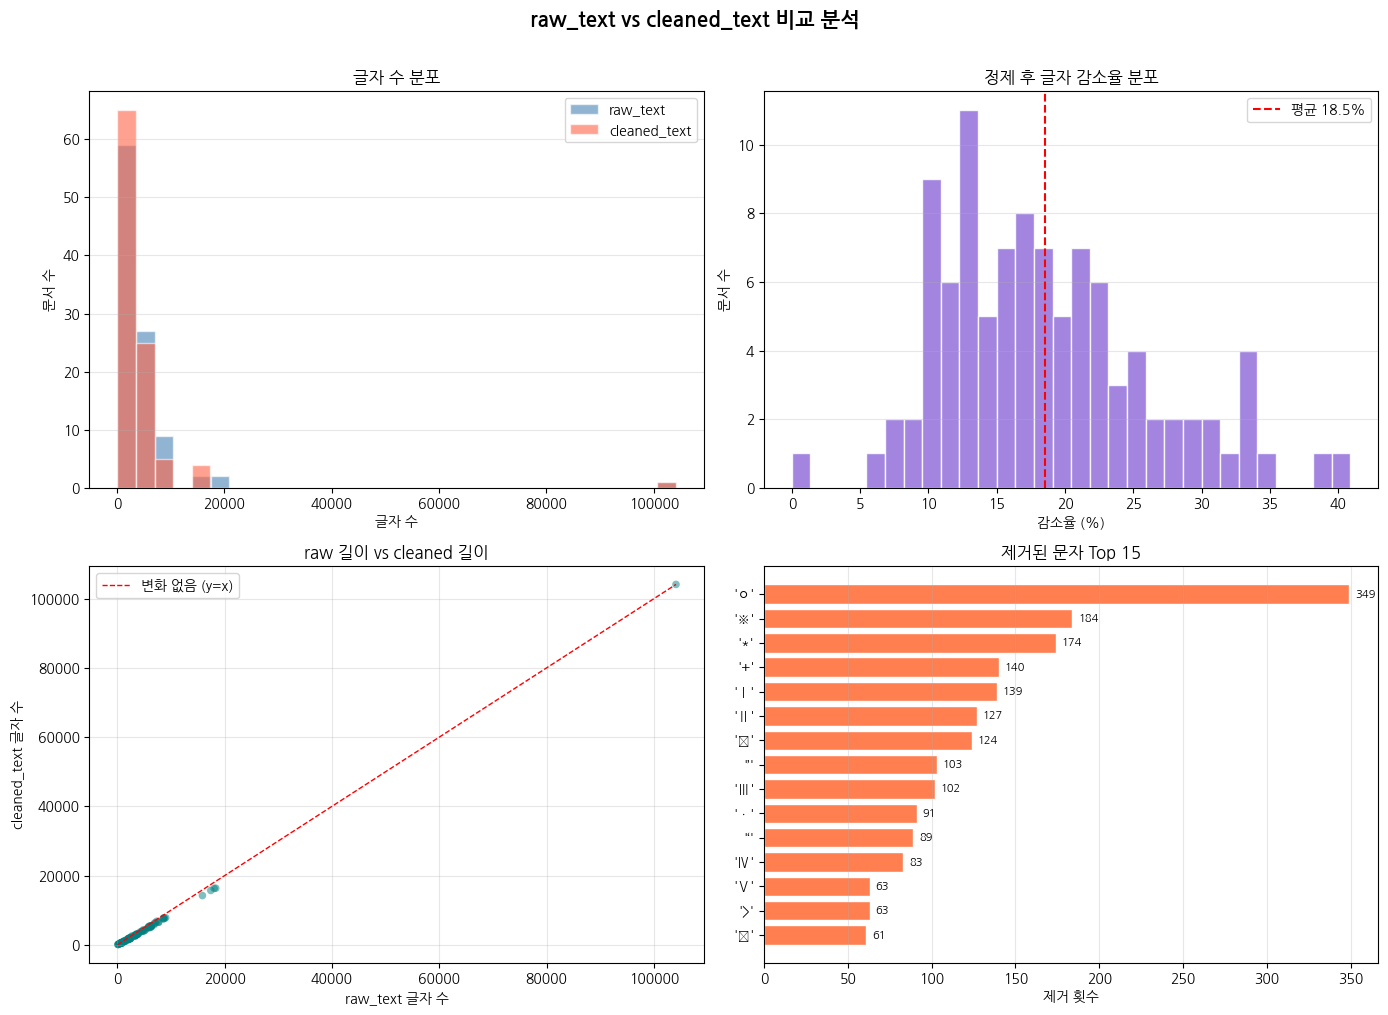


  📋 문서별 정제 통계 (처음 10건)


,파일명,raw 길이,cleaned 길이,제거 글자 수,감소율(%)
0,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,"1,799","1,206",593,33.0%
1,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,"2,792","2,347",445,15.9%
2,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,234,182,52,22.2%
3,인천광역시_도시계획위원회 통합관리시스템 구축용역.hwp,"3,143","2,581",562,17.9%
4,경상북도 봉화군_봉화군 재난통합관리시스템 고도화 사업(협상)(긴급).hwp,"5,840","4,852",988,16.9%
5,한국전기안전공사_전기안전 관제시스템 보안 모듈 개발 용역.hwp,"2,379","1,800",579,24.3%
6,재단법인충북연구원_GIS통계 기반 재난안전데이터 분석ㆍ관리 시스템 구.hwp,"2,141","1,694",447,20.9%
7,고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf,"2,450","2,123",327,13.3%
8,재단법인스포츠윤리센터_스포츠윤리센터 LMS(학습지원시스템) 기능개선.hwp,298,204,94,31.5%
9,국방과학연구소_대용량 자료전송시스템 고도화.hwp,"1,047",828,219,20.9%


In [2]:
# ================================================================
# 📊 raw_text vs cleaned_text 비교 분석
# ================================================================
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
from IPython.display import display, HTML

# ── 한글 폰트 설정 ──────────────────────────────────────────────
plt.rcParams["axes.unicode_minus"] = False

# ttflist에 실제 등록된 이름만 사용 (addfont/get_name 불필요)
_known = [
    "Malgun Gothic", "NanumGothic", "NanumBarunGothic", "NanumGothicCoding",
    "Gulim", "Dotum", "Batang", "AppleGothic", "Apple SD Gothic Neo",
]
_registered = {f.name for f in fm.fontManager.ttflist}
_found = next((f for f in _known if f in _registered), None)

# 목록에 없으면 ttflist 키워드 검색 (HCR Dotum, UnDotum 등 대응)
if _found is None:
    _kw = ["gothic", "dotum", "gulim", "batang", "nanum", "malgun", "hcr", "hangul"]
    _found = next(
        (f.name for f in fm.fontManager.ttflist
         if any(k in f.name.lower() for k in _kw)),
        None
    )

if _found:
    plt.rcParams["font.family"] = _found

# ================================================================
# 1. 정제 함수 (파이프라인과 동일한 로직)
# ================================================================
def apply_cleaning(raw_text):
    if pd.isna(raw_text) or len(str(raw_text)) == 0:
        return ""
    text = re.sub(r'[^가-힣a-zA-Z0-9\s\.\(\)\[\]\/\,\%\:\-\·\?\!\@]', ' ', str(raw_text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ================================================================
# 2. 비교 데이터프레임 생성
# ================================================================
compare_df = df[["파일명", "텍스트"]].copy().rename(columns={"텍스트": "raw_text"})
compare_df["cleaned_text"]   = compare_df["raw_text"].apply(apply_cleaning)
compare_df["raw_len"]        = compare_df["raw_text"].apply(lambda x: len(str(x)) if not pd.isna(x) else 0)
compare_df["cleaned_len"]    = compare_df["cleaned_text"].apply(len)
compare_df["removed_len"]    = compare_df["raw_len"] - compare_df["cleaned_len"]
compare_df["reduction_pct"]  = (
    compare_df["removed_len"] / compare_df["raw_len"].replace(0, 1) * 100
).round(1)

# ================================================================
# 3. 전체 통계 요약
# ================================================================
total_raw     = compare_df["raw_len"].sum()
total_cleaned = compare_df["cleaned_len"].sum()
total_removed = total_raw - total_cleaned

print("=" * 55)
print("  📊 raw_text vs cleaned_text 전체 통계")
print("=" * 55)
print(f"  문서 수          : {len(compare_df):>10,} 건")
print(f"  raw 총 글자 수   : {total_raw:>10,} 자")
print(f"  cleaned 총 글자  : {total_cleaned:>10,} 자")
print(f"  제거된 글자 수   : {total_removed:>10,} 자")
print(f"  평균 감소율      : {compare_df['reduction_pct'].mean():>9.1f} %")
print(f"  최대 감소율      : {compare_df['reduction_pct'].max():>9.1f} %")
print(f"  최소 감소율      : {compare_df['reduction_pct'].min():>9.1f} %")
print("=" * 55)

# ================================================================
# 4. 제거된 문자 종류 분석
# ================================================================
removed_chars_all = []
for _, row in compare_df.iterrows():
    raw = str(row["raw_text"]) if not pd.isna(row["raw_text"]) else ""
    removed = re.findall(r'[^가-힣a-zA-Z0-9\s\.\(\)\[\]\/\,\%\:\-\·\?\!\@]', raw)
    removed_chars_all.extend(removed)

char_counter = Counter(removed_chars_all)
top_removed  = char_counter.most_common(20)

print("\n  🗑️  가장 많이 제거된 문자 Top 20")
print("-" * 40)
max_cnt = top_removed[0][1] if top_removed else 1
for ch, cnt in top_removed:
    bar = "█" * min(int(cnt / max_cnt * 30), 30)
    print(f"  {repr(ch):>8}  {bar:<30}  {cnt:,}")

# ================================================================
# 5. 시각화 (2×2 그리드)
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("raw_text vs cleaned_text 비교 분석", fontsize=15, fontweight="bold", y=1.01)

# ── 5-1. 글자 수 분포 비교 (히스토그램) ──────────────────────
ax1 = axes[0, 0]
ax1.hist(compare_df["raw_len"],     bins=30, alpha=0.6, color="steelblue",
         label="raw_text",     edgecolor="white")
ax1.hist(compare_df["cleaned_len"], bins=30, alpha=0.6, color="tomato",
         label="cleaned_text", edgecolor="white")
ax1.set_title("글자 수 분포")
ax1.set_xlabel("글자 수")
ax1.set_ylabel("문서 수")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# ── 5-2. 감소율 분포 ─────────────────────────────────────────
ax2 = axes[0, 1]
ax2.hist(compare_df["reduction_pct"], bins=30, color="mediumpurple",
         edgecolor="white", alpha=0.85)
mean_pct = compare_df["reduction_pct"].mean()
ax2.axvline(mean_pct, color="red", linestyle="--",
            linewidth=1.5, label=f"평균 {mean_pct:.1f}%")
ax2.set_title("정제 후 글자 감소율 분포")
ax2.set_xlabel("감소율 (%)")
ax2.set_ylabel("문서 수")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

# ── 5-3. raw vs cleaned 길이 산점도 ─────────────────────────
ax3 = axes[1, 0]
ax3.scatter(compare_df["raw_len"], compare_df["cleaned_len"],
            alpha=0.5, color="teal", edgecolors="none", s=30)
max_len = max(compare_df["raw_len"].max(), compare_df["cleaned_len"].max())
ax3.plot([0, max_len], [0, max_len], "r--", linewidth=1, label="변화 없음 (y=x)")
ax3.set_title("raw 길이 vs cleaned 길이")
ax3.set_xlabel("raw_text 글자 수")
ax3.set_ylabel("cleaned_text 글자 수")
ax3.legend()
ax3.grid(alpha=0.3)

# ── 5-4. 제거 문자 Top 15 바차트 ────────────────────────────
ax4 = axes[1, 1]
if top_removed:
    top15  = top_removed[:15]
    labels = [repr(ch) for ch, _ in top15]
    counts = [cnt for _, cnt in top15]
    ax4.barh(labels[::-1], counts[::-1], color="coral", edgecolor="white")
    ax4.set_title("제거된 문자 Top 15")
    ax4.set_xlabel("제거 횟수")
    for i, cnt in enumerate(counts[::-1]):
        ax4.text(cnt + max(counts) * 0.01, i, f"{cnt:,}", va="center", fontsize=8)
    ax4.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# ================================================================
# 6. 샘플 side-by-side 비교 (상위 5건, HTML 렌더링)
# ================================================================
SAMPLE_N = 70
PREVIEW  = 1000000

def highlight_diff(raw, cleaned):
    """정제 패턴에 걸리는 문자를 직접 판별해 빨간 배경으로 마킹"""
    import html as html_mod
    result = []
    for ch in str(raw):
        if re.match(r"[^가-힣a-zA-Z0-9\s\.\(\)\[\]\/\,\%\:\-\·\?\!\@]", ch):
            result.append(f"<span style='background:#ffe0e0;color:#cc0000;'>"
                          f"{html_mod.escape(ch)}</span>")
        elif ch == "":
            result.append("<span style='color:#aaa;'>↵</span> ")
        else:
            result.append(html_mod.escape(ch))
    return "".join(result)

rows_html = []
for _, row in compare_df.head(SAMPLE_N).iterrows():
    raw     = str(row["raw_text"])[:PREVIEW]     if not pd.isna(row["raw_text"]) else ""
    cleaned = str(row["cleaned_text"])[:PREVIEW]
    fname   = str(row["파일명"])
    rows_html.append(f"""
    <tr>
      <td style='padding:8px;border:1px solid #ddd;font-size:12px;color:#555;
                 max-width:160px;word-break:break-all'>{fname}</td>
      <td style='padding:8px;border:1px solid #ddd;font-size:12px;
                 background:#fff9f9;white-space:normal;max-width:340px;'>
        {highlight_diff(raw, cleaned)}…</td>
      <td style='padding:8px;border:1px solid #ddd;font-size:12px;
                 background:#f9fff9;white-space:normal;max-width:340px;'>
        {cleaned}…</td>
      <td style='padding:8px;border:1px solid #ddd;text-align:center;
                 font-weight:bold;color:mediumpurple'>{row['reduction_pct']}%</td>
    </tr>""")

html_table = f"""
<h3 style='font-family:sans-serif'>
  🔍 샘플 비교 (상위 {SAMPLE_N}건 · 앞 {PREVIEW}자)
</h3>
<table style='border-collapse:collapse;font-family:monospace;width:100%'>
  <thead>
    <tr style='background:#f0f0f0'>
      <th style='padding:8px;border:1px solid #ddd;text-align:left'>파일명</th>
      <th style='padding:8px;border:1px solid #ddd;text-align:left'>
        raw_text <span style='color:red'>(빨강=제거된 문자)</span></th>
      <th style='padding:8px;border:1px solid #ddd;text-align:left'>cleaned_text</th>
      <th style='padding:8px;border:1px solid #ddd'>감소율</th>
    </tr>
  </thead>
  <tbody>{"".join(rows_html)}</tbody>
</table>
"""
display(HTML(html_table))

# ================================================================
# 7. 문서별 통계 테이블
# ================================================================
summary = compare_df[["파일명", "raw_len", "cleaned_len", "removed_len", "reduction_pct"]].rename(
    columns={
        "raw_len":      "raw 길이",
        "cleaned_len":  "cleaned 길이",
        "removed_len":  "제거 글자 수",
        "reduction_pct":"감소율(%)",
    }
)
print("\n  📋 문서별 정제 통계 (처음 10건)")
display(
    summary.head(10).style
    .background_gradient(subset=["감소율(%)"], cmap="RdYlGn_r")
    .format({"raw 길이": "{:,}", "cleaned 길이": "{:,}",
             "제거 글자 수": "{:,}", "감소율(%)": "{:.1f}%"})
)
